In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("../data/news_text_parsed.csv")

In [26]:
df.head()

,Дата,коррупция,взятка,подкуп,злоупотребление полномочиями,непотизм,бездействие,конфликт интересов,теневая экономика,финансовые махинации,...,заместитель,район,город,область,село,деревня,аул,правонарушение,антикор,антикора
0,2019-10-03,0,0,0,0,0,0,0,0,0,...,3,0,0,1,0,0,0,0,0,0
1,2019-10-05,2,0,0,0,0,0,0,0,0,...,0,0,0,6,0,0,0,0,0,0
2,2020-07-10,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2023-07-29,1,0,0,0,0,0,0,0,0,...,0,0,2,1,0,0,0,0,0,0
4,2019-02-19,0,2,0,0,0,0,0,0,0,...,3,0,0,0,0,0,0,0,0,0


In [27]:
# Convert the date column to datetime
df.rename(columns={"Дата": "Date"}, inplace=True)
df["Date"] = pd.to_datetime(df["Date"])

# Set the Date column as an index
df.set_index('Date', inplace=True)

# We group them by month and summarize the values for each keyword
df = df.resample('ME').sum()

In [28]:
df.head()

,коррупция,взятка,подкуп,злоупотребление полномочиями,непотизм,бездействие,конфликт интересов,теневая экономика,финансовые махинации,противодействие коррупции,...,заместитель,район,город,область,село,деревня,аул,правонарушение,антикор,антикора
Date,,,,,,,,,,,,,,,,,,,,,
2016-11-30,54,76,1,0,0,0,0,0,0,0,...,17,6,5,32,0,1,0,7,0,0
2016-12-31,40,24,0,0,0,1,0,0,0,0,...,9,4,3,14,0,0,0,6,0,0
2017-01-31,41,29,0,0,0,0,0,0,0,0,...,16,13,3,14,0,0,0,2,0,0
2017-02-28,24,16,0,0,0,0,1,0,0,0,...,3,3,9,14,0,0,0,3,0,0
2017-03-31,33,26,0,2,0,0,0,0,0,1,...,18,17,12,23,1,0,0,7,0,0


In [29]:
df.shape

(99, 86)

In [30]:
df = df.replace(0, np.nan)
df.isna().sum()

коррупция                        0
взятка                           1
подкуп                          74
злоупотребление полномочиями    93
непотизм                        96
                                ..
деревня                         97
аул                             92
правонарушение                   8
антикор                         61
антикора                        53
Length: 86, dtype: int64

In [31]:
# Drop columns with NaN percentage > 20
high_nan_count = (df.isna().sum() * 100 / df.shape[0]) >= 20
df.drop(columns=high_nan_count[high_nan_count].index, inplace=True)

In [32]:
high_nan_count[high_nan_count].index

Index(['подкуп', 'злоупотребление полномочиями', 'непотизм', 'бездействие',
       'конфликт интересов', 'теневая экономика', 'финансовые махинации',
       'противодействие коррупции', 'транспарентность', 'подотчетность',
       'мониторинг', 'уголовное дело', 'прозрачность финансирования',
       'теневые сделки', 'откат', 'откаты', 'родственник', 'расследуется',
       'лоббизм', 'незаконное обогащение', 'контроль расходов',
       'проверки деятельности', 'подозреваемый', 'подозревается', 'аудит',
       'закупка', 'госзакупки', 'госконтракт', 'электронное правительство',
       'похищение', 'отмывание', 'рейдерство', 'тенге', 'доллары', 'триллион',
       'превышение власти', 'задержали', 'уголовный кодекс',
       'получение взятки', 'незаконное вознаграждение', 'концепция',
       'мошенничество', 'легализация', 'обогатился', 'обогатились',
       'судебный процесс', 'парламент', 'мвд', 'кнб', 'депутат', 'сенат',
       'комиссия', 'конкурс', 'должностное лицо', 'служебное полож

In [33]:
# Translate keywords to english
column_translation = {
    "коррупция": "corruption",
    "взятка": "bribe",
    "приговор": "verdict",
    "хищение": "embezzlement",
    "расследование": "investigation",
    "задержание": "detention",
    "доллар": "dollar",
    "миллион": "million",
    "миллиард": "billion",
    "агентство": "agency",
    "преступление": "crime",
    "суд": "court",
    "министерство": "ministry",
    "аким": "akim",
    "начальник": "chief",
    "заместитель": "deputy",
    "район": "district",
    "город": "city",
    "область": "region",
    "правонарушение": "offense",
}

df.rename(columns=column_translation, inplace=True)


In [34]:
high_nan_count[high_nan_count].index

Index(['подкуп', 'злоупотребление полномочиями', 'непотизм', 'бездействие',
       'конфликт интересов', 'теневая экономика', 'финансовые махинации',
       'противодействие коррупции', 'транспарентность', 'подотчетность',
       'мониторинг', 'уголовное дело', 'прозрачность финансирования',
       'теневые сделки', 'откат', 'откаты', 'родственник', 'расследуется',
       'лоббизм', 'незаконное обогащение', 'контроль расходов',
       'проверки деятельности', 'подозреваемый', 'подозревается', 'аудит',
       'закупка', 'госзакупки', 'госконтракт', 'электронное правительство',
       'похищение', 'отмывание', 'рейдерство', 'тенге', 'доллары', 'триллион',
       'превышение власти', 'задержали', 'уголовный кодекс',
       'получение взятки', 'незаконное вознаграждение', 'концепция',
       'мошенничество', 'легализация', 'обогатился', 'обогатились',
       'судебный процесс', 'парламент', 'мвд', 'кнб', 'депутат', 'сенат',
       'комиссия', 'конкурс', 'должностное лицо', 'служебное полож

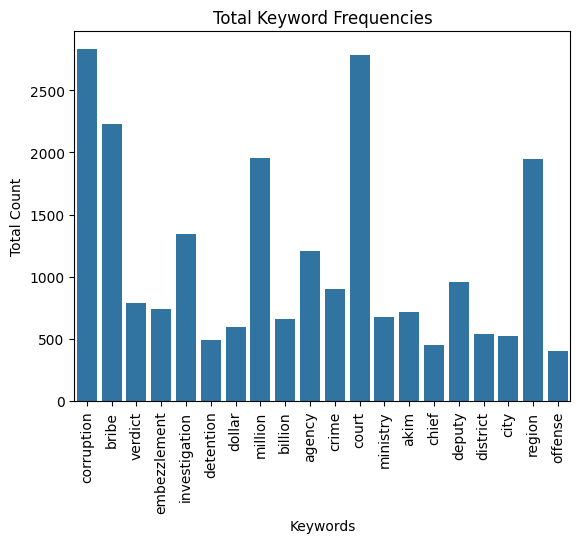

In [35]:
# Sum values for each keyword (column)
keyword_sums = df.sum()

# Create a barplot
sns.barplot(x=keyword_sums.index, y=keyword_sums.values)

# Configure plot display
plt.title('Total Keyword Frequencies')
plt.xlabel('Keywords')
plt.ylabel('Total Count')
plt.xticks(rotation=90)  # Rotate X-axis labels for better readability
plt.show()


In [36]:
df.head()

,corruption,bribe,verdict,embezzlement,investigation,detention,dollar,million,billion,agency,crime,court,ministry,akim,chief,deputy,district,city,region,offense
Date,,,,,,,,,,,,,,,,,,,,
2016-11-30,54,76.0,6.0,10.0,15.0,20.0,16.0,35.0,6.0,40.0,21.0,28.0,20.0,1.0,4.0,17.0,6.0,5.0,32.0,7.0
2016-12-31,40,24.0,2.0,4.0,11.0,7.0,3.0,15.0,1.0,24.0,6.0,16.0,13.0,6.0,3.0,9.0,4.0,3.0,14.0,6.0
2017-01-31,41,29.0,1.0,1.0,14.0,16.0,4.0,13.0,7.0,7.0,4.0,26.0,8.0,9.0,5.0,16.0,13.0,3.0,14.0,2.0
2017-02-28,24,16.0,15.0,19.0,16.0,10.0,18.0,40.0,11.0,5.0,10.0,43.0,8.0,3.0,5.0,3.0,3.0,9.0,14.0,3.0
2017-03-31,33,26.0,10.0,24.0,26.0,8.0,8.0,45.0,12.0,8.0,30.0,62.0,25.0,12.0,2.0,18.0,17.0,12.0,23.0,7.0


In [37]:
df.shape

(99, 20)

In [38]:
df.isna().sum()

corruption        0
bribe             1
verdict           6
embezzlement      9
investigation     3
detention        11
dollar           11
million           1
billion          12
agency            1
crime             2
court             2
ministry          5
akim             10
chief            18
deputy            3
district         12
city              7
region            1
offense           8
dtype: int64

In [39]:
df = df.fillna(1)

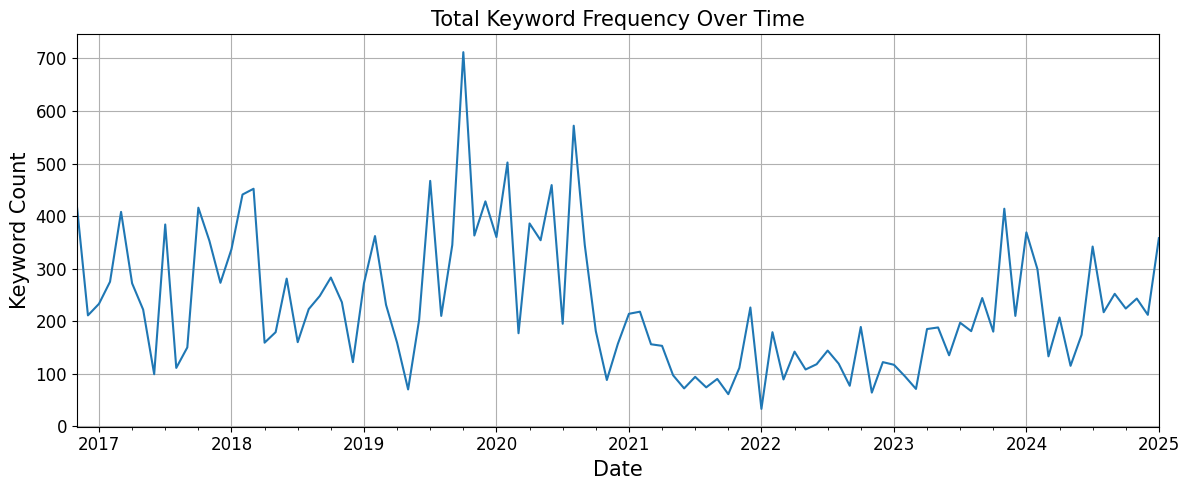

In [40]:
# Plot settings
title_size = 15
labels_size = 15
ticks_size = 12

# Calculate total keyword count per month
df_keyword_total = df.sum(axis=1)

# Plot total keyword count over time
plt.figure(figsize=(12, 5))
df_keyword_total.plot()
plt.title("Total Keyword Frequency Over Time", fontsize=title_size)
plt.xlabel("Date", fontsize=labels_size)
plt.ylabel("Keyword Count", fontsize=labels_size)
plt.xticks(fontsize=ticks_size)
plt.yticks(fontsize=ticks_size)
plt.grid(True)
plt.tight_layout()
plt.show()

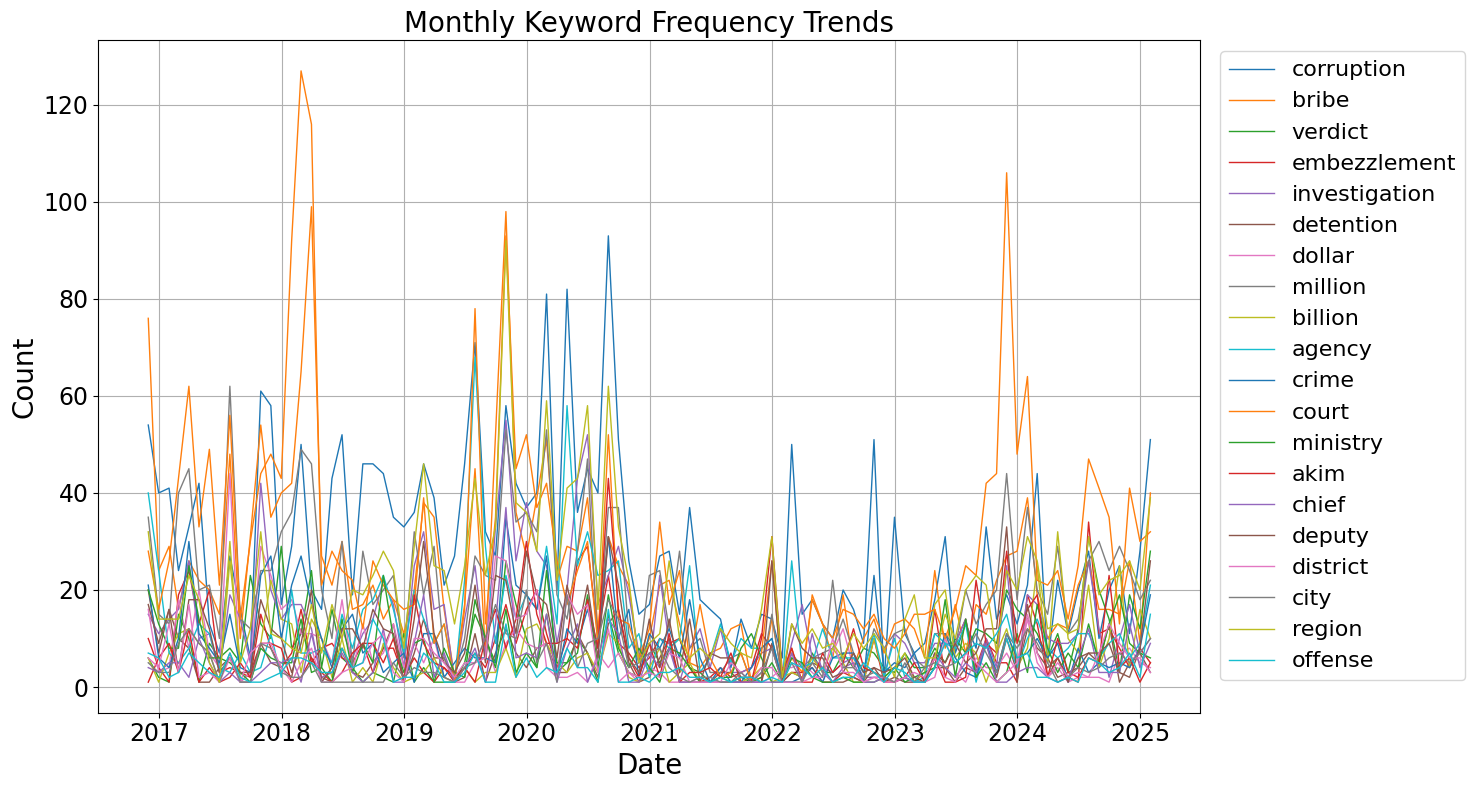

In [41]:
# Plot settings
title_size = 20
labels_size = 20
ticks_size = 17

# Plotting all keyword time series in one graph
plt.figure(figsize=(15, 8))

for column in df.columns:
    if column != "Keyword Total":  # skip the total if it's in the DataFrame
        plt.plot(df.index, df[column], label=column, linewidth=1)


plt.title("Monthly Keyword Frequency Trends", fontsize=title_size)
plt.xlabel("Date", fontsize=labels_size)
plt.ylabel("Count", fontsize=labels_size)
plt.xticks(fontsize=ticks_size)
plt.yticks(fontsize=ticks_size)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1.0), fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
df.to_csv("../data/processed_news_data.csv")